# Build the countries shapefile

Generate a shapefile with all the countries.


### Input data:

**Eurostat**: Countries 2020 — [Eurostat/GISCO administrative data](https://ec.europa.eu/eurostat/web/gisco/geodata/administrative-units/countries) © EuroGeographics for the administrative boundaries

### Input data license:

© EuroGeographics for the administrative boundaries ; Non-commercial use only

Giulia Cigna - giulia.cigna@polito.it<br>
Romain Thomas - romain.thomas@polito.it<br>
2026

In [1]:
import os
from dotenv import load_dotenv
import geopandas as gpd
import logging
import pandas as pd
from shapely.geometry import box
from shapely.geometry import MultiPolygon
from shapely.ops import unary_union
import matplotlib.pyplot as plt
import pycountry
import chardet
from pathlib import Path

## LOGGING

In [2]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",
    datefmt='%Y-%m-%d %H:%M:%S',
    force=True
)

## SETTINGS

In [3]:
if not os.path.exists(".env"):
    raise ValueError("You must create the '.env' file and set the values before running this notebook.")

load_dotenv()

True

## OUTPUT SETTINGS

In [4]:
# Get full shapefile path from environment
countries_from_eurostat_path = os.getenv("COUNTRIES_FROM_EUROSTAT_PATH")
if countries_from_eurostat_path is None:
    raise ValueError("COUNTRIES_FROM_EUROSTAT_PATH environment variable is not set")

# Create directory if it doesn't exist
Path(countries_from_eurostat_path).parent.mkdir(parents=True, exist_ok=True)

logging.info(f"Output path: {countries_from_eurostat_path}")

2026-03-13 18:00:16 - root - INFO - Output path: data/countries_from_eurostat/countries_from_eurostat.shp


## INPUT FILES

In [5]:
# Countries shapefile
eurostat_admin_countries_path = os.getenv("EUROSTAT_ADMIN_COUNTRIES_PATH")
if eurostat_admin_countries_path is None:
    raise ValueError("EUROSTAT_ADMIN_COUNTRIES_PATH environment variable is not set")

# CSV with regions ID
codes_id_path = os.getenv('CODES_ID_PATH')
if codes_id_path is None:
    raise ValueError("CODES_ID_PATH environment variable is not set")

## READING INPUT FILES

In [6]:
logging.info(f"Reading shapefile for EUROSTAT from {eurostat_admin_countries_path}")
gdf_countries = gpd.read_file(eurostat_admin_countries_path)

2026-03-13 18:00:16 - root - INFO - Reading shapefile for EUROSTAT from data/CNTR_RG_01M_2020_4326/CNTR_RG_01M_2020_4326.shp


In [7]:
logging.info(f"Reading ids from {codes_id_path}")
with open(codes_id_path, "rb") as f:
    result = chardet.detect(f.read())

# from https://pandas.pydata.org/pandas-docs/stable/user_guide/io.html#na-values
na_vals = ['-1.#IND', '1.#QNAN', '1.#IND', '-1.#QNAN', '#N/A N/A', '#N/A', 'N/A', 'n/a', 'NA', '<NA>', '#NA', 'NULL', 'null', 'NaN', '-NaN', 'nan', '-nan', 'None', '']
# avoids errors with country code "NA":
na_vals.remove('NA')

codes_id = pd.read_csv(
    codes_id_path,
    encoding=result["encoding"],
    sep=None,
    engine="python",
    keep_default_na=False,
    na_values=na_vals
)


2026-03-13 18:00:16 - root - INFO - Reading ids from ../data/codes_id.csv


## FILTER COLUMS OF INPUT FILES

In [8]:
# Scheme definition of the final shape file

schema = {
    "ID": "str:10",
    "NAME": "str:50",
    "ISO3_CODE": "str:3",
    "ISO2_CODE": "str:2",
    "ISON_CODE": "int",
    "NUM_ID": "int",
    "OL_NAME": "str:50",
    "SOURCE": "str:50",
    "geometry": "MultiPolygon"
}


Mapping between original shape file columns and finale scheme

In [9]:
# Countries
attr_countries = [c for c in gdf_countries.columns if c != "geometry"]

logging.info(f"Attributes in the Countries shape file are: {attr_countries}")

# Mapping scheme specific of EUROSTAT data
countries_columns_map = {
    'NAME_ENGL': "NAME",
    'CNTR_NAME': "OL_NAME",
    'ISO3_CODE': "ISO3_CODE",
    'CNTR_ID': "ID"
}


2026-03-13 18:00:16 - root - INFO - Attributes in the Countries shape file are: ['CNTR_ID', 'CNTR_NAME', 'NAME_ENGL', 'NAME_FREN', 'ISO3_CODE', 'SVRG_UN', 'CAPT', 'EU_STAT', 'EFTA_STAT', 'CC_STAT', 'NAME_GERM']


In [10]:
# Mapping function

def prepare_gdf(gdf, col_map, fixed_values=None):
    gdf = gdf.copy()

    # Rename columns
    gdf = gdf.rename(columns=col_map)

    # Create missing columns with placeholders
    for col in schema:
        if col not in gdf.columns and col != "geometry":
            gdf[col] = None   # placeholder

    # Apply fixed values
    if fixed_values:
        for col, val in fixed_values.items():
            gdf[col] = val

    # Keep only target columns (ORDERED by schema)
    gdf = gdf[list(schema)]

    return gdf


In [11]:
# Mapping the input gdf

gdf_countries = prepare_gdf(
    gdf_countries,
    countries_columns_map
)

logging.info(f"Attributes in the modified Countries shape file are: {gdf_countries.columns}")


2026-03-13 18:00:16 - root - INFO - Attributes in the modified Countries shape file are: Index(['ID', 'NAME', 'ISO3_CODE', 'ISO2_CODE', 'ISON_CODE', 'NUM_ID',
       'OL_NAME', 'SOURCE', 'geometry'],
      dtype='str')


## SPLIT EXTRA-TERRITORIES

Some regions contain inside more than one country. Here a function to split them.

In [12]:
# Duplicate the original gdf
gdf_countries_new = gdf_countries

# Function to split countries
def split_countries(gdf_cntr_original, gdf_cntr_final, cntr_id, split_box, row_attributes):
    """
    Split countries and adds a new row.

    Parameters:
        gdf_cntr_original: input original gdf with countries
        gdf_cntr_final: final gdf with countries
        cntr_id: big country id
        split_box: box or list of boxes that contains the areas to split
        row_attributes: list of known attributes of the country to split

    Returns:
        Updated GeoDataFrame
    """

    # Check if the target country is there or if was already processed
    if gdf_cntr_original[gdf_cntr_original["ID"] == cntr_id].empty:
        logging.info(f"Country {cntr_id} not found, skipping")
        return None
    # elif not gdf_cntr_final[gdf_cntr_final["ID"] == row_attributes["ID"]].empty:
    #     logging.info(f"Country {row_attributes['ID']} already split, skipping")
    #     return None
    else:
        logging.info(f"Country {cntr_id} processing...")


        cntr = gdf_cntr_original[gdf_cntr_original["ID"] == cntr_id]

        # Get the original country geometry
        cntr_geom = cntr.geometry.iloc[0]

        # Explode MultiPolygon into individual polygons if needed
        polygons = list(cntr_geom.geoms) if isinstance(cntr_geom, MultiPolygon) else [cntr_geom]
        polygons_gdf = gpd.GeoDataFrame(geometry=polygons, crs=gdf_cntr_original.crs)

        # Deal with both single box or list of boxes
        if not isinstance(split_box, (list, tuple)):
            split_box = [split_box]

        # Select polygons intersecting any SPLIT COUNTRY box
        split_country_parts = polygons_gdf[
            polygons_gdf.geometry.apply(
                lambda g: any(g.intersects(b) for b in split_box)
            )
        ]

        # Merge all Alaska parts into a single geometry
        split_country = split_country_parts.union_all()

        if split_country.is_empty:
            logging.warning(f"No geometry found for {row_attributes['ID']}")
            return gdf_cntr_final

        if cntr_id == row_attributes["ID"]:
            logging.info(f"Mainland processing...")

            # Changing the geometry of the big country
            gdf_cntr_final.loc[gdf_cntr_final["ID"] == cntr_id, "geometry"] = split_country

        else:
            logging.info(f"Splitting {row_attributes['ID']} from {cntr_id} ...")

            # Add the new geometry to the attributes
            row_attributes["geometry"] = split_country

            # New row definition
            new_row = gpd.GeoDataFrame(
                [row_attributes],
                geometry="geometry",
                crs=gdf_countries_new.crs
            )

            # Adding the new row to the new gdf
            gdf_cntr_final = pd.concat(
                [gdf_cntr_final, new_row],
                ignore_index=True
            )

            if gdf_cntr_final[gdf_cntr_final["ID"] == row_attributes["ID"]].empty:
                logging.info(f"Country {row_attributes['ID']} not found, splitting not done")
            else:
                logging.info(f"Country {row_attributes['ID']} split successfully and added to the final gdf")

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # 1 row, 2 columns

        # --- Original Geometry ---
        gpd.GeoSeries([cntr_geom]).plot(
            ax=axes[0],           # plot on first subplot
            color='lightblue',
            edgecolor='black',
            linewidth=1.5
        )
        axes[0].set_title(f"{cntr_id} Original Geometry", fontsize=14)
        axes[0].set_xlabel("Longitude")
        axes[0].set_ylabel("Latitude")
        axes[0].set_xlim(-180,180)
        axes[0].set_ylim(-90,90)

        # --- Split Geometry ---
        gpd.GeoSeries([split_country]).plot(
            ax=axes[1],           # plot on second subplot
            color='orange',
            edgecolor='black',
            linewidth=1.5
        )
        axes[1].set_title(f"{row_attributes['ID']} Split Geometry", fontsize=14)
        axes[1].set_xlabel("Longitude")
        axes[1].set_ylabel("Latitude")
        axes[1].set_xlim(-180,180)
        axes[1].set_ylim(-90,90)

        plt.tight_layout()  # make sure titles/labels don't overlap
        plt.show()

        return gdf_cntr_final



USA contains ALASKA and HAWAII

(-90.0, 90.0)

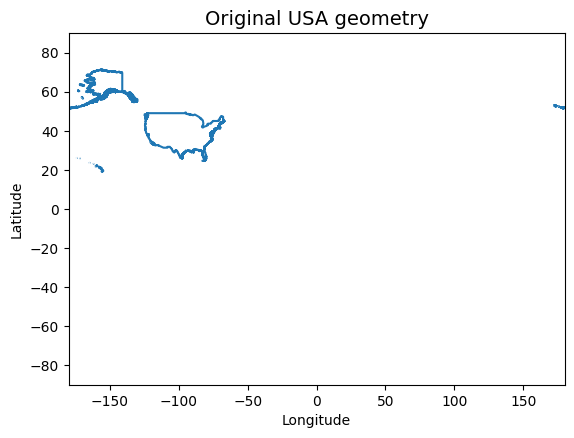

In [13]:
# USA original geometry
gdf_countries[gdf_countries["ID"] == "US"].boundary.plot()
plt.title(f"Original USA geometry", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.xlim(-180,180)
plt.ylim(-90,90)

In [14]:
# Alaska

# box definition
alaska_box = [
    box(-180, 47, -127, 73),  # main Alaska
    box(171, 50, 180, 54)     # wrap-around part
]

# attributes definition
alaska_row = {
    "NAME": "Alaska (US)",
    "ISO3_CODE": "USA",
    "ID": "AK",
    "OL_NAME": "Alaska"
}

2026-03-13 18:00:16 - root - INFO - Country US processing...
2026-03-13 18:00:17 - root - INFO - Splitting AK from US ...
2026-03-13 18:00:17 - root - INFO - Country AK split successfully and added to the final gdf


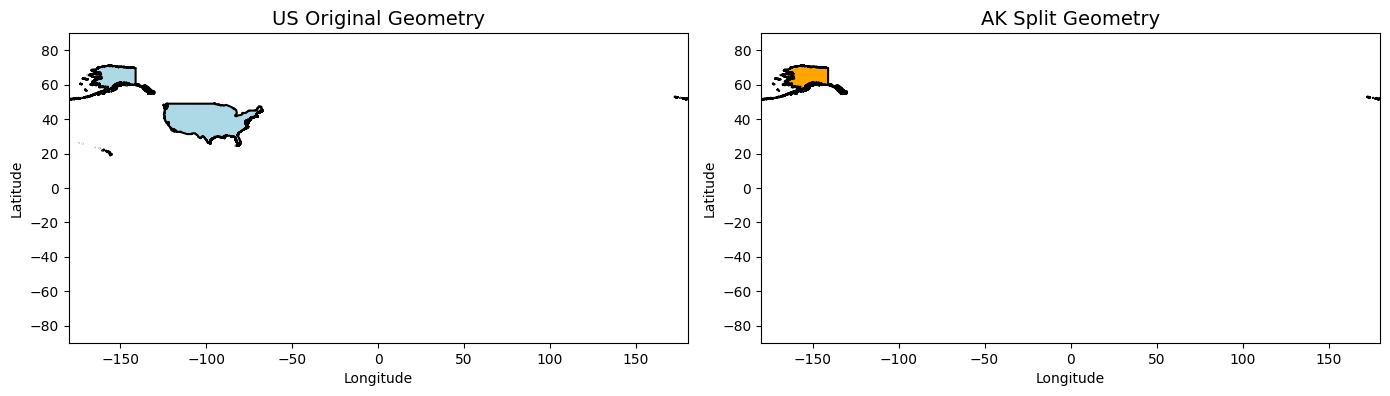

In [15]:
gdf_countries_new = split_countries(gdf_countries, gdf_countries_new, "US", alaska_box, alaska_row)

In [16]:
# Hawaii

# box definition
hawaii_box = box(-180, 18, -154, 27)

# attributes definition
hawaii_row = {
    "NAME": "Hawaii (US)",
    "ISO3_CODE": "USA",
    "ID": "HI",
    "OL_NAME": "Hawaiʻi"
}

2026-03-13 18:00:18 - root - INFO - Country US processing...
2026-03-13 18:00:18 - root - INFO - Splitting HI from US ...
2026-03-13 18:00:18 - root - INFO - Country HI split successfully and added to the final gdf


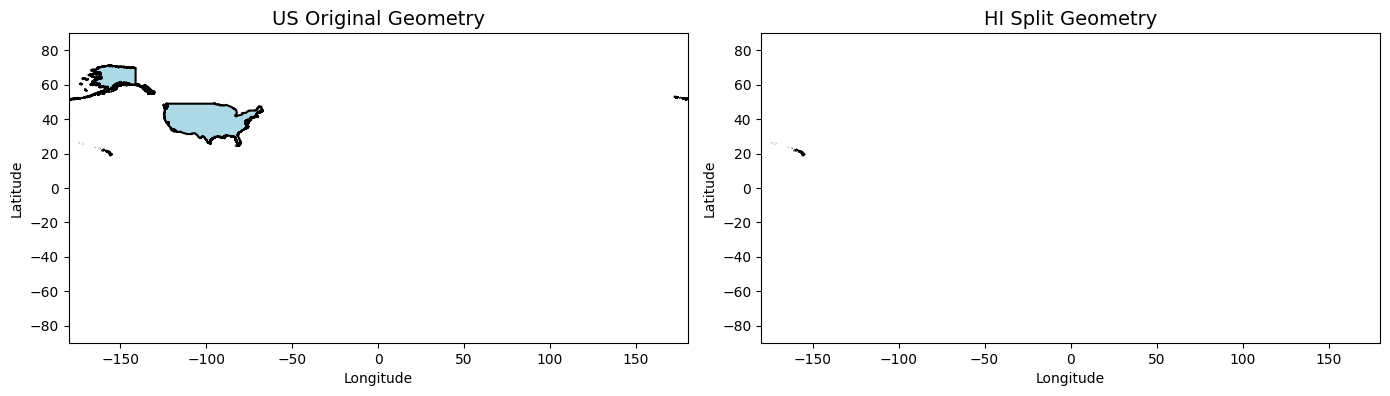

In [17]:
gdf_countries_new = split_countries(gdf_countries, gdf_countries_new, "US", hawaii_box, hawaii_row)

In [18]:
# Continental US

# box definition
conus_box = box(-125, 24, -66.5, 50)

# attributes definition
conus_row = {
    "ID": "US"
}

2026-03-13 18:00:18 - root - INFO - Country US processing...
2026-03-13 18:00:18 - root - INFO - Mainland processing...


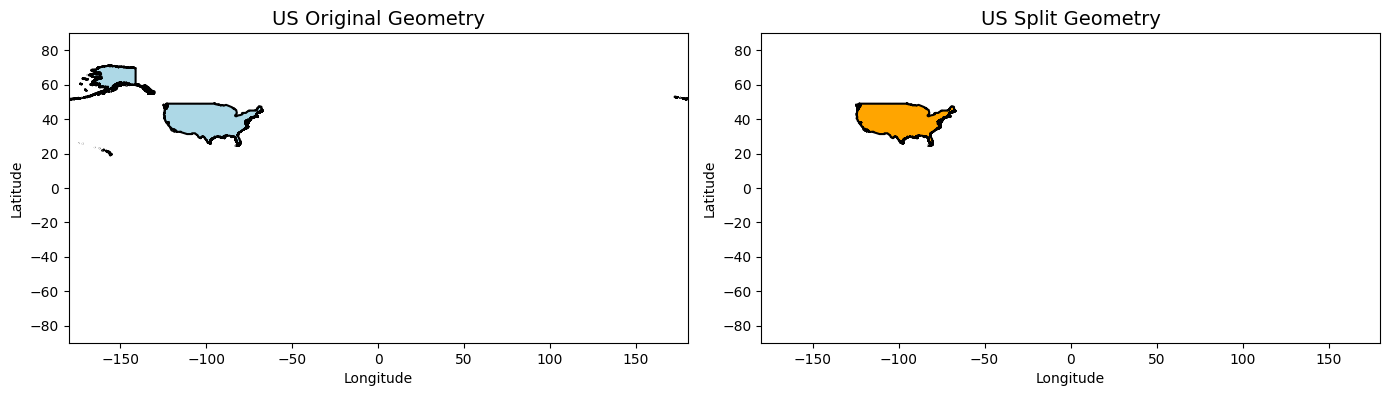

In [19]:
gdf_countries_new = split_countries(gdf_countries, gdf_countries_new, "US", conus_box, conus_row)

CHINA contains TAIWAN

(-90.0, 90.0)

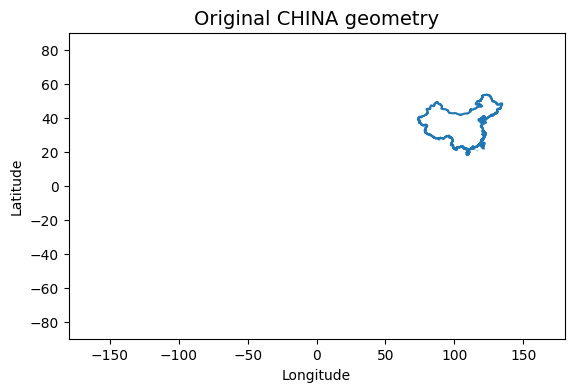

In [20]:
# CHINA original geometry
gdf_countries[gdf_countries["ID"] == "CN"].boundary.plot()
plt.title(f"Original CHINA geometry", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.xlim(-180,180)
plt.ylim(-90,90)

In [21]:
# Taiwan

# box definition
taiwan_box = unary_union([box(119.8, 21.5, 123, 25.4), box(119, 23, 119.8, 24)])

# attributes definition
taiwan_row = {
    "NAME": "Taiwan",
    "ISO3_CODE": "TWN",
    "ID": "TW",
    "OL_NAME": "中華民國"
}

2026-03-13 18:00:19 - root - INFO - Country CN processing...
2026-03-13 18:00:19 - root - INFO - Splitting TW from CN ...
2026-03-13 18:00:19 - root - INFO - Country TW split successfully and added to the final gdf


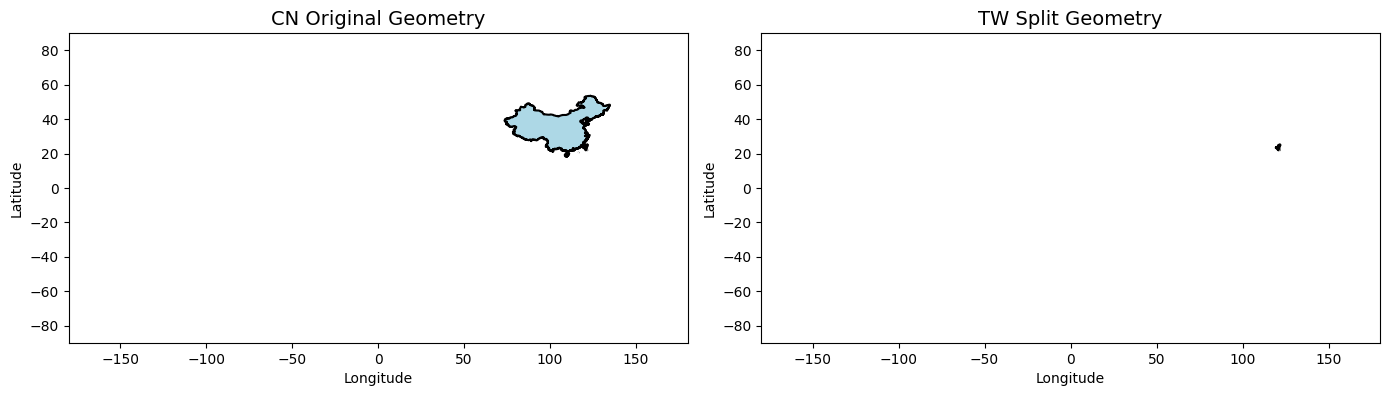

In [22]:
gdf_countries_new = split_countries(gdf_countries, gdf_countries_new, "CN", taiwan_box, taiwan_row)

In [23]:
# China mainland

# box definition
chn_box = box(70, 15, 140, 55) - taiwan_box

# attributes definition
chn_row = {
    "ID": "CN"
}

2026-03-13 18:00:20 - root - INFO - Country CN processing...
2026-03-13 18:00:20 - root - INFO - Mainland processing...


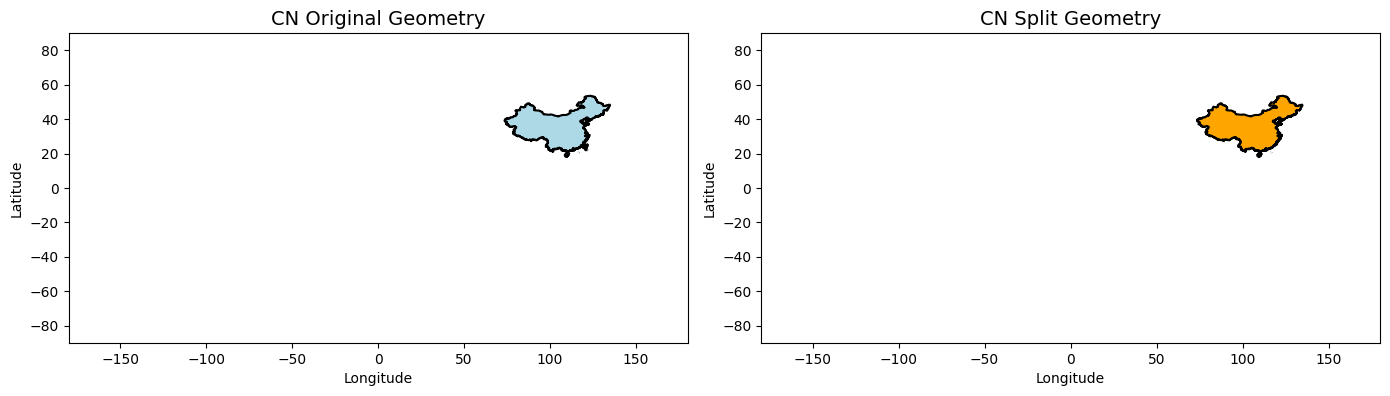

In [24]:
gdf_countries_new = split_countries(gdf_countries, gdf_countries_new, "CN", chn_box, chn_row)

FRANCE contains FRENCH GUIANA, GUADALUPE, MARTINIQUE, SAINT MARTIN, MAYOTTE, REUNION

(-90.0, 90.0)

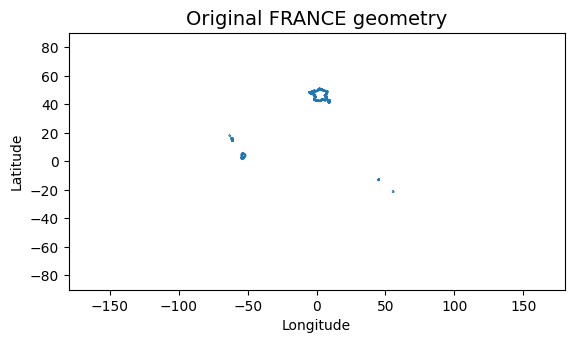

In [25]:
# FRANCE original geometry
gdf_countries[gdf_countries["ID"] == "FR"].boundary.plot()
plt.title(f"Original FRANCE geometry", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.xlim(-180,180)
plt.ylim(-90,90)

In [26]:
# French Guiana

# box definition
frguiana_box = box(-55, 1.5, -51, 6)

# attributes definition
frguiana_row = {
    "NAME": "French Guiana",
    "ISO3_CODE": "GUF",
    "ID": "GF",
    "OL_NAME": "Guyane"
}

2026-03-13 18:00:20 - root - INFO - Country FR processing...
2026-03-13 18:00:20 - root - INFO - Splitting GF from FR ...
2026-03-13 18:00:20 - root - INFO - Country GF split successfully and added to the final gdf


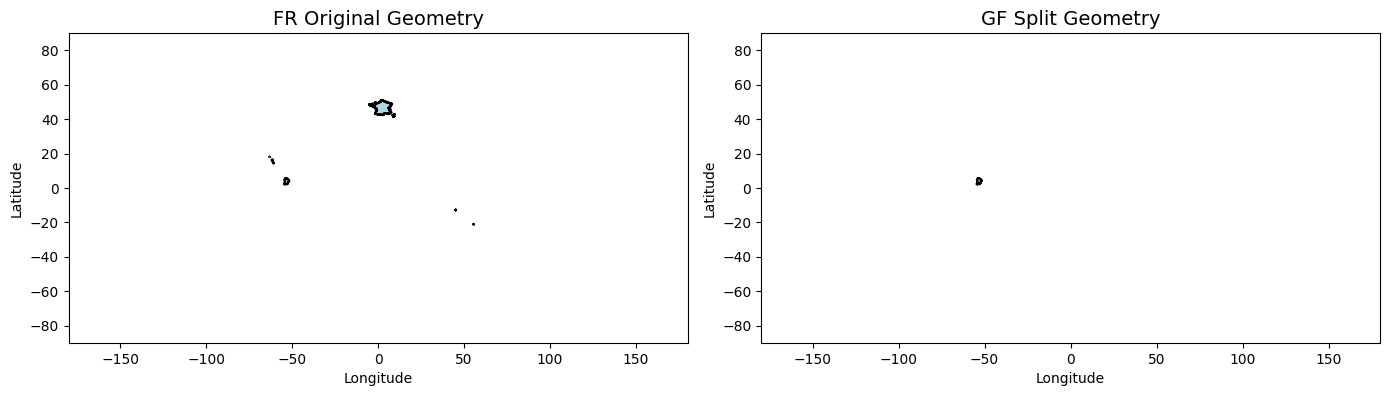

In [27]:
gdf_countries_new = split_countries(gdf_countries, gdf_countries_new, "FR", frguiana_box, frguiana_row)

In [28]:
# Guadeloupe

# box definition
guad_box = box(-60, 15.5, -62, 17)

# attributes definition
guad_row = {
    "NAME": "Guadeloupe",
    "ISO3_CODE": "GLP",
    "ID": "GP",
    "OL_NAME": "Guadeloupe"
}

2026-03-13 18:00:20 - root - INFO - Country FR processing...
2026-03-13 18:00:20 - root - INFO - Splitting GP from FR ...
2026-03-13 18:00:20 - root - INFO - Country GP split successfully and added to the final gdf


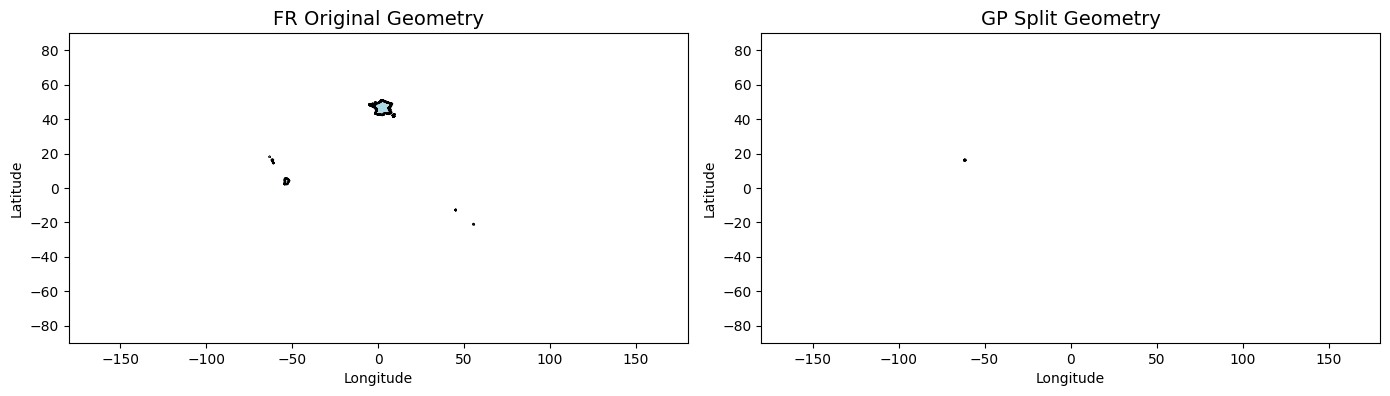

In [29]:
gdf_countries_new = split_countries(gdf_countries, gdf_countries_new, "FR", guad_box, guad_row)

In [30]:
# Martinique

# box definition
mart_box = box(-60, 14, -62, 15)

# attributes definition
mart_row = {
    "NAME": "Martinique",
    "ISO3_CODE": "MTQ",
    "ID": "MQ",
    "OL_NAME": "Martinique"
}

2026-03-13 18:00:21 - root - INFO - Country FR processing...
2026-03-13 18:00:21 - root - INFO - Splitting MQ from FR ...
2026-03-13 18:00:21 - root - INFO - Country MQ split successfully and added to the final gdf


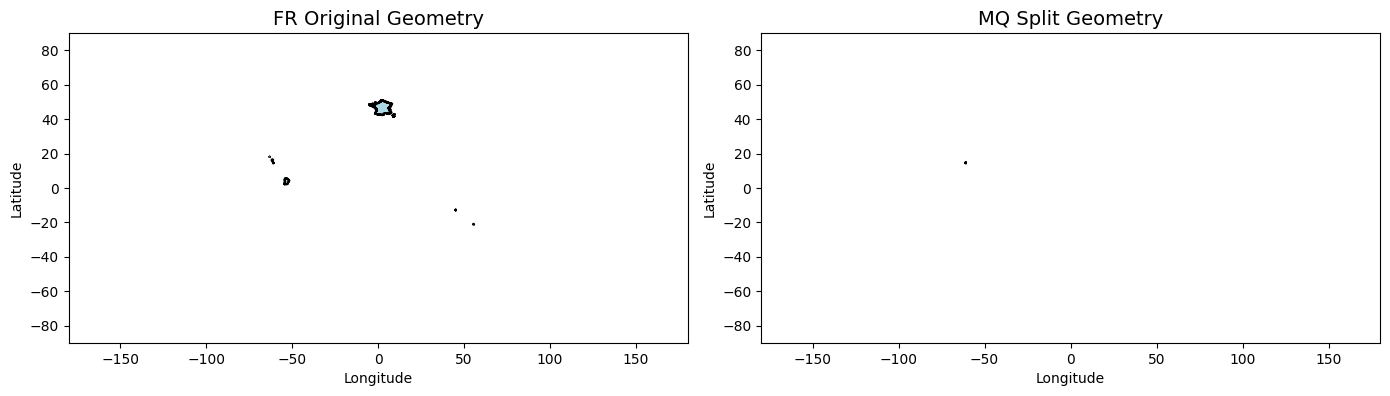

In [31]:
gdf_countries_new = split_countries(gdf_countries, gdf_countries_new, "FR", mart_box, mart_row)

In [32]:
# Saint Martin

# box definition
shn_box = box(-63.3, 18, -62.8, 18.2)

# attributes definition
shn_row = {
    "NAME": "Saint Martin",
    "ISO3_CODE": "MAF",
    "ID": "MF",
    "OL_NAME": "Saint Martin"
}

2026-03-13 18:00:21 - root - INFO - Country FR processing...
2026-03-13 18:00:21 - root - INFO - Splitting MF from FR ...
2026-03-13 18:00:21 - root - INFO - Country MF split successfully and added to the final gdf


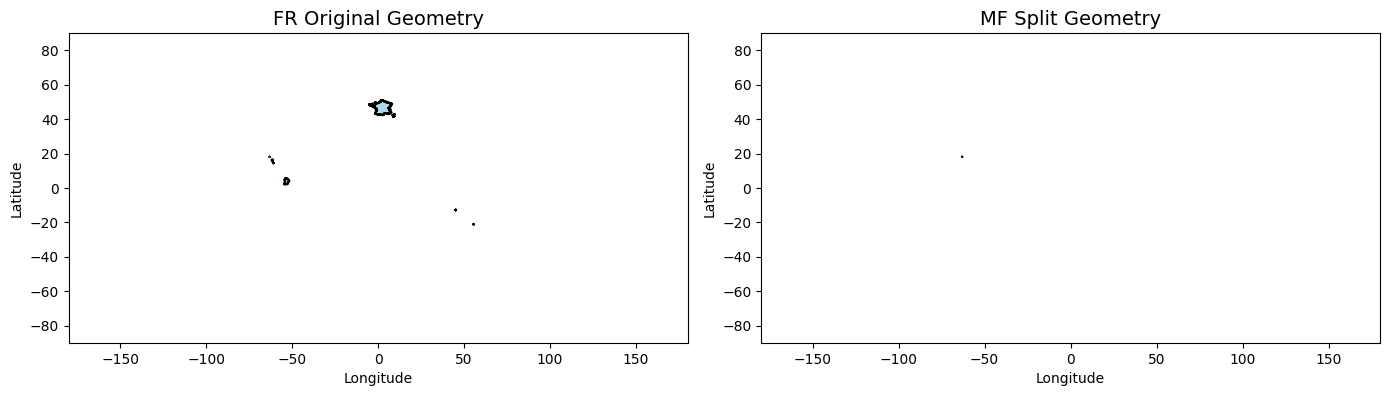

In [33]:
gdf_countries_new = split_countries(gdf_countries, gdf_countries_new, "FR", shn_box, shn_row)

In [34]:
# Mayotte

# box definition
mayotte_box = box(44, -13.5, 45.5, -12.5)

# attributes definition
mayotte_row = {
    "NAME": "Mayotte",
    "ISO3_CODE": "MYT",
    "ID": "YT",
    "OL_NAME": "Mayotte"
}

2026-03-13 18:00:21 - root - INFO - Country FR processing...
2026-03-13 18:00:21 - root - INFO - Splitting YT from FR ...
2026-03-13 18:00:21 - root - INFO - Country YT split successfully and added to the final gdf


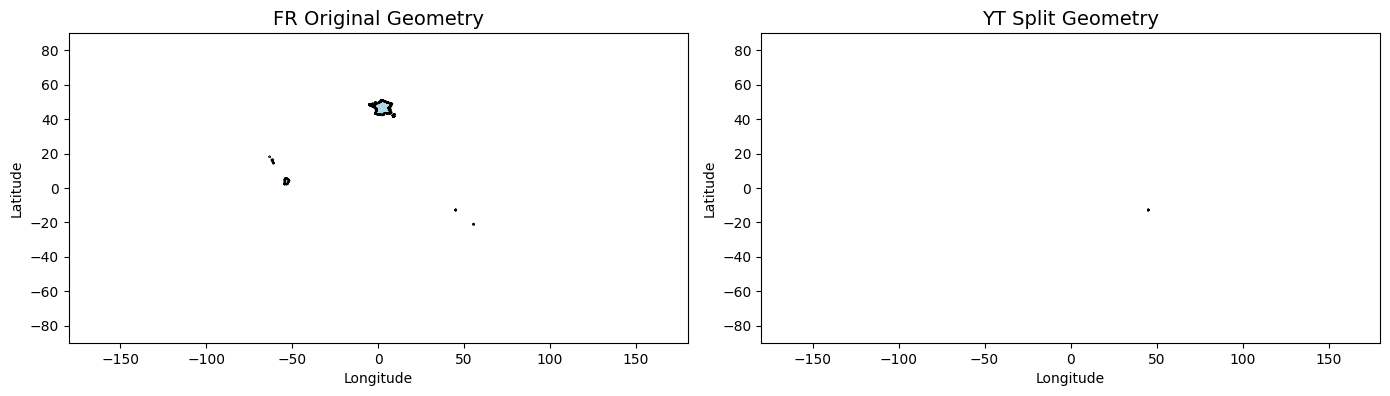

In [35]:
gdf_countries_new = split_countries(gdf_countries, gdf_countries_new, "FR", mayotte_box, mayotte_row)

In [36]:
# Réunion

# box definition
reunion_box = box(54, -22, 56, -20)

# attributes definition
reunion_row = {
    "NAME": "Réunion",
    "ISO3_CODE": "REU",
    "ID": "RE",
    "OL_NAME": "Réunion"
}

2026-03-13 18:00:21 - root - INFO - Country FR processing...
2026-03-13 18:00:21 - root - INFO - Splitting RE from FR ...
2026-03-13 18:00:21 - root - INFO - Country RE split successfully and added to the final gdf


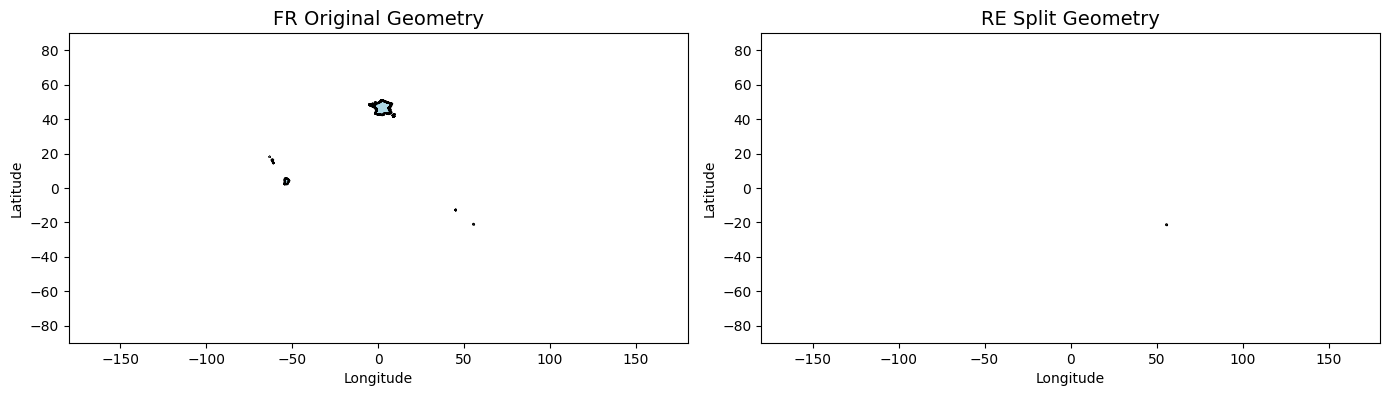

In [37]:
gdf_countries_new = split_countries(gdf_countries, gdf_countries_new, "FR", reunion_box, reunion_row)

In [38]:
# France (Europe)

# box definition
france_box = box(-70, -25, 70, 70) - frguiana_box - reunion_box - mayotte_box - guad_box - mart_box - shn_box

# attributes definition
france_row = {
    "ID": "FR"
}

2026-03-13 18:00:21 - root - INFO - Country FR processing...
2026-03-13 18:00:22 - root - INFO - Mainland processing...


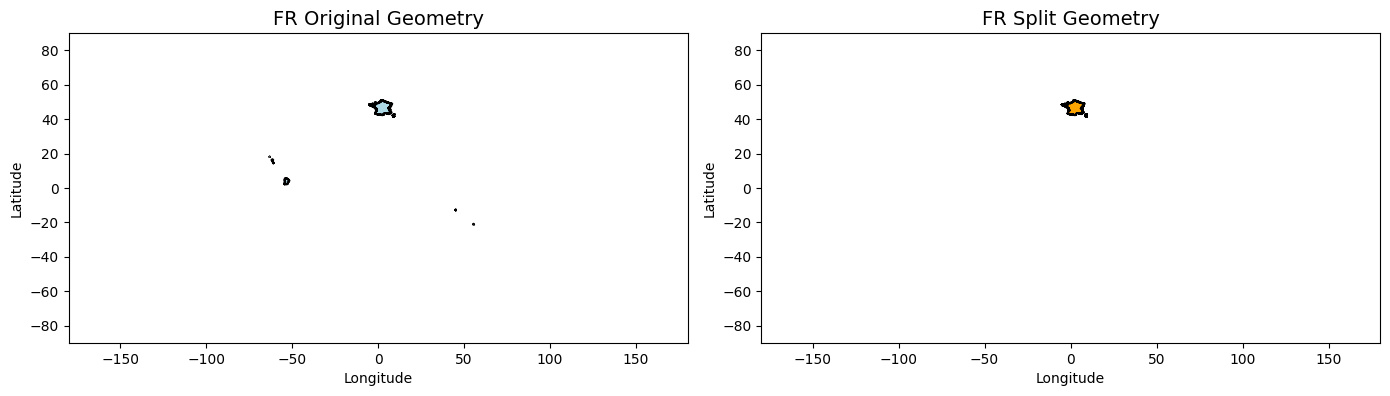

In [39]:
gdf_countries_new = split_countries(gdf_countries, gdf_countries_new, "FR", france_box, france_row)

Splitting processed finished

In [40]:
logging.info("Countries splitting processed finished")

2026-03-13 18:00:22 - root - INFO - Countries splitting processed finished


## METADATA

Fill empty metadata

In [41]:
# All the countries are sourced from EUROSTAT
gdf_countries_new["SOURCE"] = "EUROSTAT"


In [42]:
# Functions to assign other ISO codes from: Countries (ISO 3166-1)
def iso3_to_iso2(code):
    country = pycountry.countries.get(alpha_3=code)
    return country.alpha_2 if country else None

def iso3_to_num(code):
    country = pycountry.countries.get(alpha_3=code)
    return country.numeric if country else None

# Assign codes
gdf_countries_new["ISO2_CODE"] = gdf_countries_new["ISO3_CODE"].apply(iso3_to_iso2)
gdf_countries_new["ISON_CODE"] = gdf_countries_new["ISO3_CODE"].apply(iso3_to_num)


In [43]:
# Add the NUM_ID from the csv file
lookup = codes_id.set_index("ID")["NUM_ID"]
gdf_countries_new["NUM_ID"] = gdf_countries_new["ID"].map(lookup)
gdf_countries_new["NUM_ID"] = gdf_countries_new["NUM_ID"].astype(str).str.strip()
gdf_countries_new["NUM_ID"] = pd.to_numeric(gdf_countries_new["NUM_ID"], errors='coerce').astype('Int64')

## SAVING OUTPUT FILE

In [44]:
# Save GeoDataFrame
gdf_countries_new.to_file(countries_from_eurostat_path)

logging.info(f"Saved Shapefile to: {countries_from_eurostat_path}")

2026-03-13 18:00:22 - pyogrio._io - INFO - Created 266 records
2026-03-13 18:00:22 - root - INFO - Saved Shapefile to: data/countries_from_eurostat/countries_from_eurostat.shp
